
# Домашнее задание. Обучение с подкреплением

В этом задании последовательно разбираются ключевые идеи обучения с подкреплением: описание среды как марковского процесса принятия решений, вычисление функции ценности, улучшение стратегии, методы Монте-Карло, Temporal Difference, а также алгоритмы управления SARSA и Q-learning.

Работа построена как единый экспериментальный сценарий. Сначала рассматривается небольшая табличная среда GridWorld, на которой удобно проверять формулы и сравнивать точные и выборочные методы. Затем изучается среда Cliff Walking, где хорошо видны различия между осторожным и рискованным поведением алгоритмов управления.

## Структура домашнего задания

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности.

| Уровень | Задачи | Содержание |
|---|---:|---|
| Простые | 1–4 | MDP, эпизоды, дисконтированная доходность, оценка и улучшение стратегии |
| Средние | 5–7 | Monte Carlo, TD(0), SARSA |
| Сложные | 8–9 | Сравнение SARSA и Q-learning, абляции по исследованию |

## Теоретическая часть

### Марковский процесс принятия решений

Среда обучения с подкреплением обычно задается пятеркой
$$\mathrm{M} = (\mathrm{S}, \mathrm{A}, P, R, \gamma),$$
где $\mathrm{S}$ — множество состояний, $\mathrm{A}$ — множество действий, $P(s'\mid s,a)$ — вероятность перехода, $R(s,a,s')$ — награда, а $\gamma \in [0,1]$ — коэффициент дисконтирования.

### Доходность и функция ценности

Для последовательности наград $r_{t+1}, r_{t+2}, \dots$ дисконтированная доходность определяется как
$$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}.$$

Функция ценности состояния для стратегии $\pi$ имеет вид
$$V^{\pi}(s) = \mathbb{E}_{\pi}[G_t \mid s_t=s].$$

### Уравнение Беллмана

Для фиксированной стратегии выполняется рекуррентное соотношение
$$V^{\pi}(s) = \sum_{a} \pi(a\mid s) \sum_{s'} P(s'\mid s,a) \left[R(s,a,s') + \gamma V^{\pi}(s')\right].$$

Если стратегия табличная и детерминированная, то для каждого состояния выбирается одно действие, и вычисление упрощается.

### Выборочные методы

В методах Monte Carlo оценка строится по завершенным эпизодам, а в TD-методах обновление делается после каждого шага:
$$V(s_t) \leftarrow V(s_t) + \alpha \left(r_{t+1} + \gamma V(s_{t+1}) - V(s_t)\right).$$

### Управление

Для управления в задаче обучения с подкреплением оценивается не только состояние, но и ценность пары «состояние-действие»:
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left(\text{target} - Q(s_t,a_t)\right).$$

В SARSA целевое значение зависит от фактически выбранного следующего действия:
$$\text{target}_{\text{SARSA}} = r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}),$$
а в Q-learning используется максимум по действиям:
$$\text{target}_{\text{Q-learning}} = r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a').$$

### Гипотезы домашнего задания

В задании проверяются следующие гипотезы:

1. Точная оценка по уравнению Беллмана дает устойчивый ориентир для сравнения выборочных методов.
2. При ограниченном числе эпизодов TD(0) распространяет информацию быстрее, чем Monte Carlo.
3. В Cliff Walking алгоритм SARSA чаще обучается более осторожному поведению, а Q-learning — более рискованному, но потенциально более выгодному.
4. Режим исследования $\varepsilon$-greedy заметно влияет на скорость и качество обучения.

## Настройка окружения

In [23]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

SEED = 42
rng = np.random.default_rng(SEED)

ACTION_NAMES = ['В', 'П', 'Н', 'Л']
ACTION_DELTAS = {
    0: (-1, 0),  # вверх
    1: (0, 1),   # вправо
    2: (1, 0),   # вниз
    3: (0, -1),  # влево
}
LEFT_OF = {0: 3, 1: 0, 2: 1, 3: 2}
RIGHT_OF = {0: 1, 1: 2, 2: 3, 3: 0}


class SlipperyGridWorld:
    """
        Объект-среда скользкого мира-сетки с ямами, целью
        и вероятностью соскальзывания в ямку
    """
    def __init__(
        self,
        n_rows=4,
        n_cols=4,
        start=(0, 0),
        goal=(3, 3),
        holes=((2, 1), (2, 2), (3, 2)),
        slip_prob=0.2,
        step_reward=-0.04,
        hole_reward=-1.0,
        goal_reward=1.0,
        seed=SEED,
    ):
        """
            Инициализация среды с заданными размерами, наградами
            и вероятностью соскальзывания
        """
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.start = start
        self.goal = goal
        self.holes = set(holes)
        self.slip_prob = slip_prob
        self.step_reward = step_reward
        self.hole_reward = hole_reward
        self.goal_reward = goal_reward
        self.n_actions = 4
        self.n_states = n_rows * n_cols
        self.rng = np.random.default_rng(seed)
        self.terminal_states = {self.pos_to_state(goal)} | {self.pos_to_state(h) for h in self.holes}
        self.reset()

    def pos_to_state(self, pos):
        """
            Метод перевода координат (row, col) в номер состояния
        """
        r, c = pos
        return r * self.n_cols + c

    def state_to_pos(self, state):
        """
            Метод перевода номера состояния в координаты (row, col)
        """
        return divmod(state, self.n_cols)

    def is_terminal(self, state):
        """
            Метод проверки состояния на терминальность
        """
        return state in self.terminal_states

    def _move(self, state, action):
        """
            Метод вычисляет следующее состояние после действия
            (без учёта стохастичности)
        """
        r, c = self.state_to_pos(state)
        dr, dc = ACTION_DELTAS[action]
        nr = min(max(r + dr, 0), self.n_rows - 1)
        nc = min(max(c + dc, 0), self.n_cols - 1)
        return self.pos_to_state((nr, nc))

    def reward_for_state(self, state):
        """
            Метод возвращает немедленную награду
            при переходе в указанное состояние
        """
        pos = self.state_to_pos(state)
        if pos == self.goal:
            return self.goal_reward
        if pos in self.holes:
            return self.hole_reward
        return self.step_reward

    def transition_distribution(self, state, action):
        """
            Метод возвращает список (вероятность, след. состояние, награда, done)
            для (state, action)
        """
        if self.is_terminal(state):
            return [(1.0, state, 0.0, True)]

        candidate_actions = [
            (1.0 - self.slip_prob, action),
            (self.slip_prob / 2.0, LEFT_OF[action]),
            (self.slip_prob / 2.0, RIGHT_OF[action]),
        ]

        merged = {}
        for prob, actual_action in candidate_actions:
            next_state = self._move(state, actual_action)
            reward = self.reward_for_state(next_state)
            done = self.is_terminal(next_state)
            key = (next_state, reward, done)
            merged[key] = merged.get(key, 0.0) + prob

        return [(prob, ns, rew, done) for (ns, rew, done), prob in merged.items()]

    def build_dynamics(self):
        """
            Метод строит матрицы переходов(P), наград (G)
            и маску терминальных состояний (done_mask)
        """
        P = np.zeros((self.n_states, self.n_actions, self.n_states))
        G = np.zeros((self.n_states, self.n_actions, self.n_states))
        done_mask = np.zeros((self.n_states, self.n_actions, self.n_states), dtype=bool)

        for s in range(self.n_states):
            for a in range(self.n_actions):
                for prob, ns, rew, done in self.transition_distribution(s, a):
                    P[s, a, ns] += prob
                    G[s, a, ns] = rew
                    done_mask[s, a, ns] = done
        return P, G, done_mask

    def reset(self):
        """
            Мтод сбрасывает среду в начальное состояние
        """
        self.state = self.pos_to_state(self.start)
        return self.state

    def step(self, action):
        """
            Метод выполняет шаг(действие) в среде
        """
        transitions = self.transition_distribution(self.state, action)
        probs = [item[0] for item in transitions]
        idx = self.rng.choice(len(transitions), p=probs)
        _, next_state, reward, done = transitions[idx]
        self.state = next_state
        return next_state, reward, done, {}

    def render(self, values=None, policy=None, title='GridWorld'):
        """
            Метод визуализирует сетку (V и политика опционально)
        """
        grid = np.zeros((self.n_rows, self.n_cols))
        for h in self.holes:
            grid[h] = -1
        grid[self.goal] = 1

        _, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid)
        ax.set_title(title)
        ax.set_xticks(np.arange(self.n_cols))
        ax.set_yticks(np.arange(self.n_rows))
        ax.set_xticks(np.arange(-0.5, self.n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.n_rows, 1), minor=True)
        ax.grid(which='minor', linewidth=1.5)

        for s in range(self.n_states):
            r, c = self.state_to_pos(s)
            lines = [f's={s}']
            if values is not None:
                lines.append(f'V={values[s]:.2f}')
            if policy is not None:
                lines.append('T' if self.is_terminal(s) else ACTION_NAMES[int(policy[s])])
            ax.text(c, r, '\n'.join(lines), ha='center', va='center', fontsize=9)

        plt.show()


class CliffWalking:
    def __init__(self, n_rows=4, n_cols=12, seed=SEED):
        """
            Инициализация начального состояния среды: 
            старт (внизу слева), обрыв, цель (внизу справа)
        """
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.n_states = n_rows * n_cols
        self.n_actions = 4
        self.start = (n_rows - 1, 0)
        self.goal = (n_rows - 1, n_cols - 1)
        self.cliff = {(n_rows - 1, c) for c in range(1, n_cols - 1)}
        self.rng = np.random.default_rng(seed)
        self.reset()

    def pos_to_state(self, pos):
        """
            Метод переводит координаты в номер состояния
        """
        r, c = pos
        return r * self.n_cols + c

    def state_to_pos(self, state):
        """
            Метод переводит номер состояния в координаты
        """
        return divmod(state, self.n_cols)

    def reset(self):
        """
            Мтод сбрасывает среду в начальное состояние
        """
        self.state = self.pos_to_state(self.start)
        return self.state

    def step(self, action):
        """
            Метод действия
        """
        r, c = self.state_to_pos(self.state)
        dr, dc = ACTION_DELTAS[action]
        nr = min(max(r + dr, 0), self.n_rows - 1)
        nc = min(max(c + dc, 0), self.n_cols - 1)
        next_pos = (nr, nc)

        if next_pos in self.cliff:
            reward = -100.0
            next_state = self.pos_to_state(self.start)
            done = False
        elif next_pos == self.goal:
            reward = -1.0
            next_state = self.pos_to_state(next_pos)
            done = True
        else:
            reward = -1.0
            next_state = self.pos_to_state(next_pos)
            done = False

        self.state = next_state
        return next_state, reward, done, {}

    def render(self, q_values=None, policy=None, title='Cliff Walking'):
        """
            Метод отображает среду (с Q‑value и/или политикой)
        """
        grid = np.zeros((self.n_rows, self.n_cols))
        for cell in self.cliff:
            grid[cell] = -1
        grid[self.goal] = 1
        grid[self.start] = 0.5

        _, ax = plt.subplots(figsize=(12, 4))
        ax.imshow(grid)
        ax.set_title(title)
        ax.set_xticks(np.arange(self.n_cols))
        ax.set_yticks(np.arange(self.n_rows))
        ax.set_xticks(np.arange(-0.5, self.n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.n_rows, 1), minor=True)
        ax.grid(which='minor', linewidth=1.5)

        for s in range(self.n_states):
            r, c = self.state_to_pos(s)
            pos = (r, c)
            lines = []
            if pos == self.start:
                lines.append('S')
            elif pos == self.goal:
                lines.append('G')
            elif pos in self.cliff:
                lines.append('C')
            else:
                lines.append(f's={s}')

            if q_values is not None and pos not in self.cliff and pos != self.goal:
                lines.append(f'{np.max(q_values[s]):.1f}')
            if policy is not None and pos not in self.cliff and pos != self.goal:
                lines.append(ACTION_NAMES[int(policy[s])])

            ax.text(c, r, '\n'.join(lines), ha='center', va='center', fontsize=8)

        plt.show()


def simulate_episode(env, policy, max_steps=100):
    """
        Генерирует эпизод по заданной политике
    """
    states, actions, rewards = [], [], []
    state = env.reset()

    for _ in range(max_steps):
        states.append(state)
        action = int(policy[state]) if np.ndim(policy) == 1 else env.rng.choice(env.n_actions, p=policy[state])
        actions.append(action)
        next_state, reward, done, _ = env.step(action)
        rewards.append(reward)
        state = next_state
        if done:
            states.append(state)
            break

    return states, actions, rewards


def discounted_returns(rewards, gamma):
    """
        Функция вычисляет дисконтированные доходы g_t для списка наград
    """
    out = np.zeros(len(rewards))
    g = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        g = rewards[t] + gamma * g
        out[t] = g
    return out


def policy_evaluation(P, G, policy, gamma=0.95, theta=1e-8, max_iter=10_000, return_history=False):
    """
        Функция оценки ценности для политики
    """
    n_states = P.shape[0]
    V = np.zeros(n_states)
    history = [V.copy()]

    for _ in range(max_iter):
        delta = 0.0
        V_new = V.copy()
        for s in range(n_states):
            a = int(policy[s])
            V_new[s] = np.sum(P[s, a] * (G[s, a] + gamma * V))
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            break

    if return_history:
        return V, history
    return V


def action_value_from_V(P, G, V, state, gamma=0.95):
    """
        Функция вычисляет Q(s, a) по известной V и переходам
    """
    q_values = np.zeros(P.shape[1])
    for a in range(P.shape[1]):
        q_values[a] = np.sum(P[state, a] * (G[state, a] + gamma * V))
    return q_values


def policy_improvement(P, G, V, terminal_states=None, gamma=0.95):
    """
        Функция улучшения политики 
        путём преобразования её в жадную относительно V
    """
    n_states = P.shape[0]
    policy = np.zeros(n_states, dtype=int)
    terminal_states = set() if terminal_states is None else set(terminal_states)

    for s in range(n_states):
        if s in terminal_states:
            policy[s] = 0
        else:
            q_values = action_value_from_V(P, G, V, s, gamma=gamma)
            policy[s] = int(np.argmax(q_values))
    return policy


def policy_iteration(P, G, terminal_states=None, gamma=0.95, max_rounds=100):
    """
        Функция вычисления оптимальной политики и V
    """
    n_states = P.shape[0]
    policy = np.zeros(n_states, dtype=int)
    terminal_states = set() if terminal_states is None else set(terminal_states)

    for s in terminal_states:
        policy[s] = 0

    history = []
    for _ in range(max_rounds):
        V = policy_evaluation(P, G, policy, gamma=gamma)
        new_policy = policy_improvement(P, G, V, terminal_states=terminal_states, gamma=gamma)
        history.append((policy.copy(), V.copy()))
        if np.array_equal(new_policy, policy):
            break
        policy = new_policy

    V = policy_evaluation(P, G, policy, gamma=gamma)
    history.append((policy.copy(), V.copy()))
    return policy, V, history


def first_visit_mc_evaluation(env, policy, gamma=0.95, n_episodes=1000, seed=SEED, reference_V=None):
    """
        Функция оценки ценности методом Монте-Карло первого посещения
    """
    local_env = SlipperyGridWorld(
        n_rows=env.n_rows,
        n_cols=env.n_cols,
        start=env.start,
        goal=env.goal,
        holes=tuple(env.holes),
        slip_prob=env.slip_prob,
        step_reward=env.step_reward,
        hole_reward=env.hole_reward,
        goal_reward=env.goal_reward,
        seed=seed,
    )

    returns_sum = np.zeros(local_env.n_states)
    returns_count = np.zeros(local_env.n_states)
    V = np.zeros(local_env.n_states)
    errors = []

    for _ in range(n_episodes):
        states, _, rewards = simulate_episode(local_env, policy, max_steps=100)
        G_episode = discounted_returns(rewards, gamma)
        visited = set()

        for t, s in enumerate(states[:-1]):
            if s not in visited:
                visited.add(s)
                returns_sum[s] += G_episode[t]
                returns_count[s] += 1
                V[s] = returns_sum[s] / returns_count[s]

        if reference_V is not None:
            mask = returns_count > 0
            err = np.mean((V[mask] - reference_V[mask]) ** 2) if np.any(mask) else np.nan
            errors.append(err)

    return V, returns_count, np.array(errors)


def td0_evaluation(env, policy, gamma=0.95, alpha=0.1, n_episodes=500, seed=SEED, reference_V=None):
    """
        Функция оценки ценности методом TD(0)
    """
    local_env = SlipperyGridWorld(
        n_rows=env.n_rows,
        n_cols=env.n_cols,
        start=env.start,
        goal=env.goal,
        holes=tuple(env.holes),
        slip_prob=env.slip_prob,
        step_reward=env.step_reward,
        hole_reward=env.hole_reward,
        goal_reward=env.goal_reward,
        seed=seed,
    )

    V = np.zeros(local_env.n_states)
    errors = []

    for _ in range(n_episodes):
        s = local_env.reset()
        done = False
        steps = 0
        while not done and steps < 100:
            a = int(policy[s])
            s_next, r, done, _ = local_env.step(a)
            td_target = r if done else r + gamma * V[s_next]
            V[s] += alpha * (td_target - V[s])
            s = s_next
            steps += 1

        if reference_V is not None:
            errors.append(np.mean((V - reference_V) ** 2))

    return V, np.array(errors)


def epsilon_greedy(Q, state, epsilon, rng):
    """
        Функция возвращает результат действия
        по epsilon жадной стратегии относительно Q
    """
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    return int(np.argmax(Q[state]))


def sarsa(env, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=400, max_steps=500, seed=SEED):
    """
        Функция обучения Sarsa на политике
        с жадным исследованием epsilon
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    episode_returns = []

    for _ in range(n_episodes):
        s = env.reset()
        a = epsilon_greedy(Q, s, epsilon, rng)
        total_reward = 0.0

        for _ in range(max_steps):
            s_next, r, done, _ = env.step(a)
            total_reward += r
            a_next = epsilon_greedy(Q, s_next, epsilon, rng)
            target = r if done else r + gamma * Q[s_next, a_next]
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = s_next, a_next
            if done:
                break

        episode_returns.append(total_reward)

    return Q, np.array(episode_returns)


def q_learning(env, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=400, max_steps=500, seed=SEED, epsilon_decay=None):
    """
        Функция обученя Q‑learning вне политики
        с опциональным затуханием epsilon.
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    episode_returns = []

    for episode in range(n_episodes):
        s = env.reset()
        total_reward = 0.0

        if epsilon_decay is None:
            epsilon_now = epsilon
        else:
            epsilon_now = max(
                epsilon_decay['min_epsilon'],
                epsilon * (epsilon_decay['decay_rate'] ** episode)
            )

        for _ in range(max_steps):
            a = epsilon_greedy(Q, s, epsilon_now, rng)
            s_next, r, done, _ = env.step(a)
            total_reward += r
            target = r if done else r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (target - Q[s, a])
            s = s_next
            if done:
                break

        episode_returns.append(total_reward)

    return Q, np.array(episode_returns)


def greedy_policy_from_Q(Q):
    """
        Функция извлекает жадную детерминированную политику
        из Q-функции
    """
    return np.argmax(Q, axis=1)


def rollout_greedy(env, Q, max_steps=100):
    """
        Функция выполняет жадное разыгрывание по Q,
        возвращает траекторию и сумму наград
    """
    s = env.reset()
    trajectory = [s]
    total_reward = 0.0
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        s_next, r, done, _ = env.step(a)
        trajectory.append(s_next)
        total_reward += r
        s = s_next
        if done:
            break
    return trajectory, total_reward


def mse(a, b, mask=None):
    """
        Функция вычисляет среднеквадратичную ошибку
        между a и b по маске (если указана)
    """
    if mask is None:
        return np.mean((a - b) ** 2)
    return np.mean((a[mask] - b[mask]) ** 2)


def moving_average(x, window=20):
    """
        Функция сглаживает одномерный массив скользящим средним
    """
    if len(x) < window:
        return np.array(x)
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='valid')


print('Окружение и вспомогательные функции готовы.')

Окружение и вспомогательные функции готовы.


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

В этом блоке отрабатываются базовые идеи: структура среды, эпизод, дисконтированная доходность, функция ценности и улучшение стратегии.

## Задача 1. Построение среды и анализ размерностей

### Постановка задачи

Создайте табличную среду `SlipperyGridWorld`, постройте тензоры переходов и наград, проверьте корректность размерностей и вероятностных распределений.

### Теоретический минимум

Если в среде $|\mathrm{S}| = S$ состояний и $|\mathrm{A}| = A$ действий, то:
- тензор переходов имеет форму $(S, A, S)$;
- тензор наград имеет ту же форму;
- для любой пары $(s, a)$ сумма вероятностей перехода по всем $s'$ должна быть равна 1.

Число состояний: 16
Число действий: 4
Форма тензора переходов P: (16, 4, 16)
Форма тензора наград G: (16, 4, 16)
Форма маски терминальных переходов: (16, 4, 16)

Минимальная сумма вероятностей по (s, a): 1.0
Максимальная сумма вероятностей по (s, a): 1.0

Переходы из стартового состояния при действии "вправо":
  p=0.80, s_next=1, reward=-0.04, done=False
  p=0.10, s_next=0, reward=-0.04, done=False
  p=0.10, s_next=4, reward=-0.04, done=False


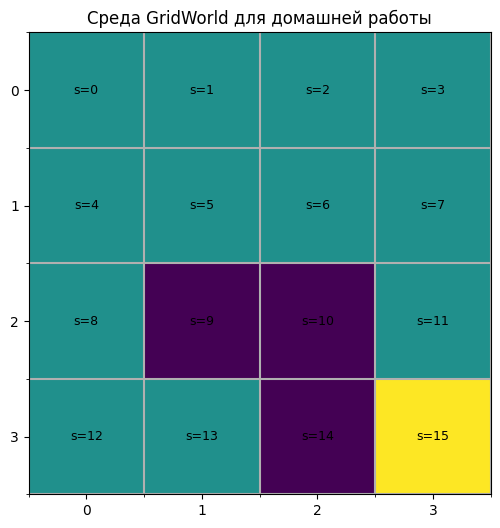

In [24]:
# Задача 1


gamma = 0.95
env = SlipperyGridWorld(slip_prob=0.2, seed=SEED)

# DONE: Постройте тензоры переходов и наград
P, G, done_mask = env.build_dynamics()

print('Число состояний:', env.n_states)
print('Число действий:', env.n_actions)
print('Форма тензора переходов P:', P.shape)
print('Форма тензора наград G:', G.shape)
print('Форма маски терминальных переходов:', done_mask.shape)

# DONE: Проверьте, что для каждой пары (s, a) сумма вероятностей равна 1
row_sums = P.sum(axis=2)
print('\nМинимальная сумма вероятностей по (s, a):', row_sums.min())
print('Максимальная сумма вероятностей по (s, a):', row_sums.max())

# DONE: Выведите возможные переходы из стартового состояния при действии "вправо" (action=1)
start_state = env.pos_to_state((0, 0))
print('\nПереходы из стартового состояния при действии "вправо":')
for prob, ns, rew, done in env.transition_distribution(start_state, 1):
    print(f'  p={prob:.2f}, s_next={ns}, reward={rew:.2f}, done={done}')

env.render(title='Среда GridWorld для домашней работы')

### Интерпретация результата



## Задача 2. Один эпизод и дисконтированная доходность

### Постановка задачи

Задайте простую детерминированную стратегию, которая сначала ведет агента вправо, а затем вниз. Смоделируйте один эпизод и вычислите дисконтированные доходности $G_t$.

### Теоретический минимум

Для конечного эпизода доходность вычисляется с конца:
$$G_t = r_{t+1} + \gamma G_{t+1}.$$
Чем дальше по времени расположена награда, тем слабее ее вклад при $\gamma < 1$.

**Зачем это нужно:** дисконтированная доходность — основа всего RL: именно ее мы пытаемся максимизировать.

**Подсказки для размышления:**
- Как закодировать стратегию «сначала вправо, потом вниз» в виде массива `policy` длины 16?
- Почему вычисление $G_t$ идет с конца последовательности, а не с начала?
- Что должно происходить с $G_t$ по мере приближения к терминальному состоянию?

**Полезные инструменты:** `simulate_episode()`, `discounted_returns()`, `ACTION_NAMES`, `np.arange()`.

Состояния эпизода: [0, 1, 2, 2, 3, 7, 6, 7, 11, 15]
Действия эпизода: ['П', 'П', 'П', 'П', 'Н', 'Н', 'П', 'Н', 'Н']
Награды: [-0.04 -0.04 -0.04 -0.04 -0.04 -0.04 -0.04 -0.04  1.  ]
Доходности G_t: [0.394 0.457 0.523 0.593 0.666 0.743 0.824 0.91  1.   ]


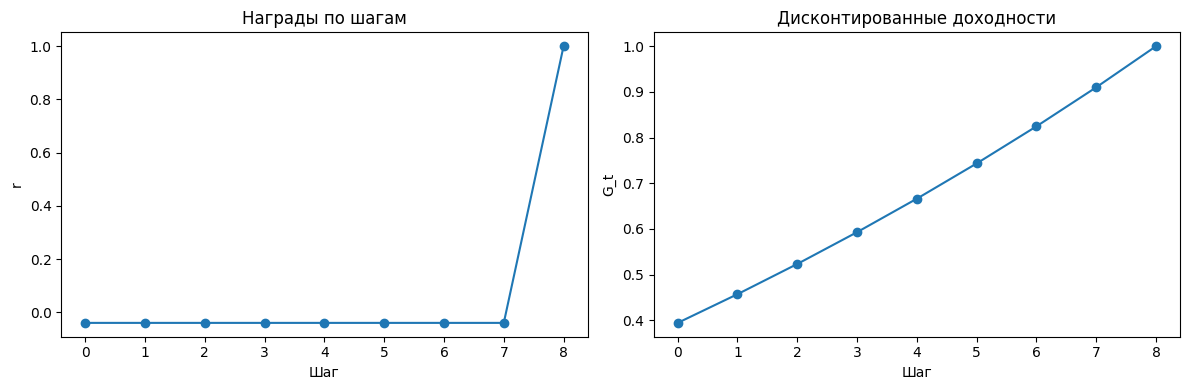

In [25]:
# Задача 2


# DONE: Задайте детерминированную стратегию 4x4 (16 состояний):
# действие 1 = вправо, действие 2 = вниз
# Стратегия: в каждой строке идем вправо до конца, затем вниз
right_then_down_policy = np.array([
    # ваш код здесь — 16 целых чисел, по одному на каждое состояние
    1 if (s % 4) < 3 else 2 for s in range(16)
], dtype=int)

# DONE: Смоделируйте один эпизод с помощью simulate_episode
states, actions, rewards = simulate_episode(env, right_then_down_policy)

# DONE: Вычислите дисконтированные доходности
returns = discounted_returns(rewards, gamma)

print('Состояния эпизода:', states)
print('Действия эпизода:', [ACTION_NAMES[a] for a in actions])
print('Награды:', np.round(rewards, 3))
print('Доходности G_t:', np.round(returns, 3))

# DONE: Постройте два графика рядом:
# левый — награды по шагам, правый — дисконтированные доходности
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =========================== График Награды по шагам ==========================
axes[0].plot(rewards, marker='o', linestyle='-')
axes[0].set_title('Награды по шагам')
axes[0].set_xlabel('Шаг')
axes[0].set_ylabel('r')

# ===================== График Дисконтированные доходности =====================
axes[1].plot(returns, marker='o', linestyle='-')
axes[1].set_title('Дисконтированные доходности')
axes[1].set_xlabel('Шаг')
axes[1].set_ylabel('G_t')

plt.tight_layout()
plt.show()

### Интерпретация результата

## Задача 3. Оценка фиксированной стратегии через уравнение Беллмана

### Постановка задачи

Для стратегии из предыдущей задачи найдите функцию ценности $V^{\pi}(s)$ методом итеративной оценки стратегии и проследите, как она меняется по итерациям.

### Теоретический минимум

Итеративная оценка стратегии повторяет обновление
$$V_{k+1}(s) = \sum_{s'} P(s'\mid s, \pi(s)) \bigl(R(s, \pi(s), s') + \gamma V_k(s')\bigr),$$
пока изменения не станут достаточно малыми.

**Зачем это нужно:** точная оценка $V^\pi$ станет эталоном для проверки выборочных методов в следующих задачах.

**Подсказки для размышления:**
- Сколько итераций нужно до сходимости? Зависит ли это от структуры среды?
- Почему значения $V$ у целевого состояния выше, а у ям — ниже?
- Как итоговая тепловая карта связана с тем, насколько «хороша» стратегия?

**Полезные инструменты:** `policy_evaluation()`, `.reshape(env.n_rows, env.n_cols)`, `ax.imshow()`, `ax.text()`

Число итераций до сходимости: 29
Функция ценности для фиксированной стратегии:
[[ 0.262  0.358  0.454  0.544]
 [ 0.051  0.199  0.396  0.643]
 [-0.896  0.     0.     0.769]
 [-0.977 -0.999  0.     0.   ]]


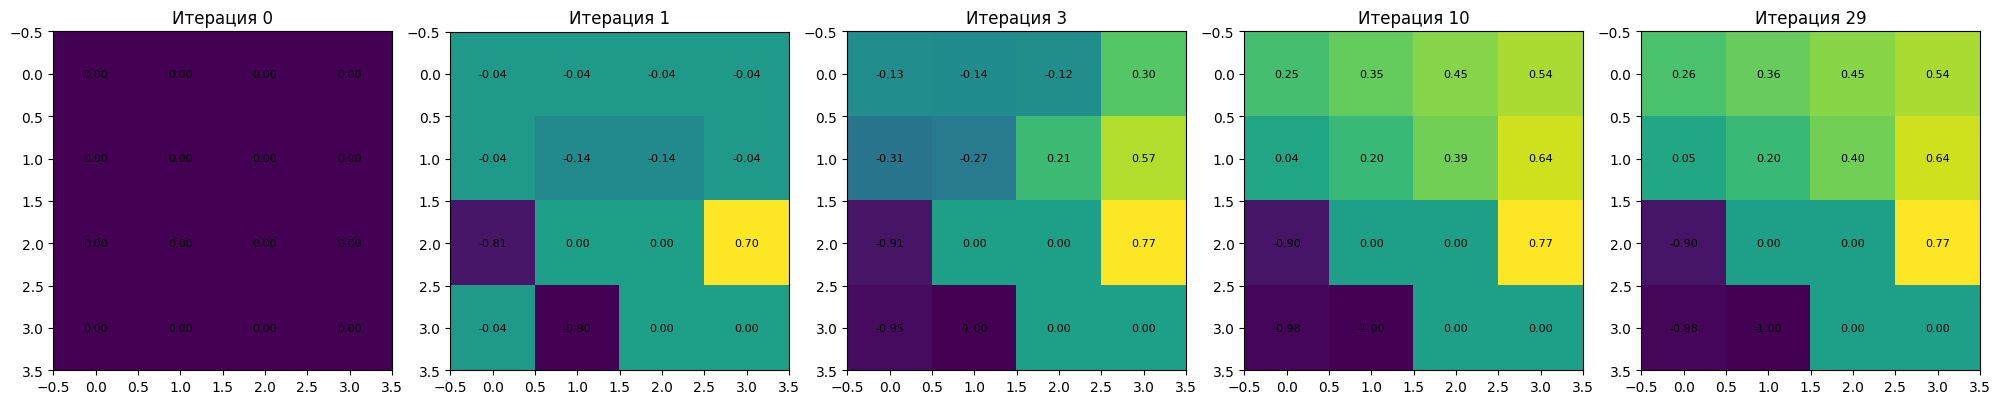

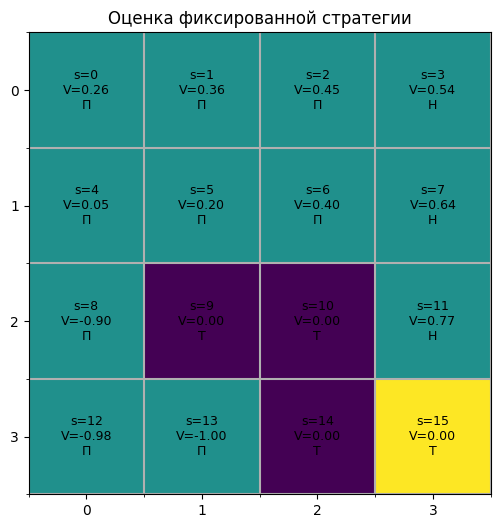

In [26]:
# Задача 3


# DONE: Вычислите функцию ценности для right_then_down_policy
# Используйте return_history=True, чтобы получить историю сходимости
V_pi, history = policy_evaluation(
    P,  # тензор переходов
    G,  # тензор наград
    right_then_down_policy,  # стратегия
    gamma=gamma,
    return_history=True,
)

print('Число итераций до сходимости:', len(history) - 1)
print('Функция ценности для фиксированной стратегии:')
print(np.round(V_pi.reshape(env.n_rows, env.n_cols), 3))

# DONE: Визуализируйте функцию ценности в нескольких контрольных итерациях
# Выберите итерации: 0, 1, 3, 10 (или меньше, если не сошлось), последнюю
selected_iterations = [0, 1, 3, min(10, len(history) - 1), len(history) - 1]
selected_iterations = sorted(set(selected_iterations))

fig, axes = plt.subplots(
    1,
    len(selected_iterations),
    figsize=(4 * len(selected_iterations), 4)
)
if len(selected_iterations) == 1:
    axes = [axes]

for ax, idx in zip(axes, selected_iterations):
    grid = history[idx].reshape(env.n_rows, env.n_cols)
    ax.imshow(grid)
    ax.set_title(f'Итерация {idx}')
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            ax.text(
                c,
                r,
                f'{grid[r, c]:.2f}',
                ha='center',
                va='center',
                fontsize=8
            )

plt.tight_layout()
plt.show()

# DONE: Отрисуйте среду с наложенными значениями V_pi и стратегией
env.render(
    values=V_pi,
    policy=right_then_down_policy,
    title='Оценка фиксированной стратегии'
)

### Интерпретация результата

## Задача 4. Улучшение стратегии и policy iteration

### Постановка задачи

Используя найденную функцию ценности, выполните жадное улучшение стратегии. Затем запустите полную `policy iteration` и сравните исходную и оптимальную стратегии.

### Теоретический минимум

Если функция ценности уже оценена, то можно вычислить
$$Q(s,a) = \sum_{s'} P(s'\mid s,a) \left[R(s,a,s') + \gamma V(s')\right],$$
после чего выбрать действие с максимальным значением. Повторение шагов «оценка → улучшение» приводит к `policy iteration`.

**Зачем это нужно:** `Policy iteration` — классический алгоритм точного решения MDP; его результат станет эталоном для сравнения с выборочными методами.

**Подсказки для размышления:**
- Почему `policy_improvement` берет `argmax` по Q-значениям, а не по V?
- Что значит, что ценность стартового состояния выросла после `policy iteration`?
- Сколько раундов нужно `policy iteration` до сходимости? Почему обычно немного?

**Полезные инструменты:** `policy_improvement()`, `policy_iteration()`, `.reshape()`, `env.pos_to_state()`

Жадно улучшенная стратегия после одной оценки:
[[1 1 1 2]
 [0 0 1 2]
 [0 0 0 2]
 [0 3 0 0]]

Оптимальная стратегия после policy iteration:
[[1 1 1 2]
 [0 0 1 2]
 [0 0 0 2]
 [0 3 0 0]]

Функция ценности оптимальной стратегии:
[[ 0.289  0.368  0.454  0.544]
 [ 0.23   0.299  0.396  0.643]
 [ 0.043  0.     0.     0.769]
 [-0.026 -0.172  0.     0.   ]]

Ценность стартового состояния:
  исходная стратегия  : 0.262
  оптимальная стратегия: 0.289


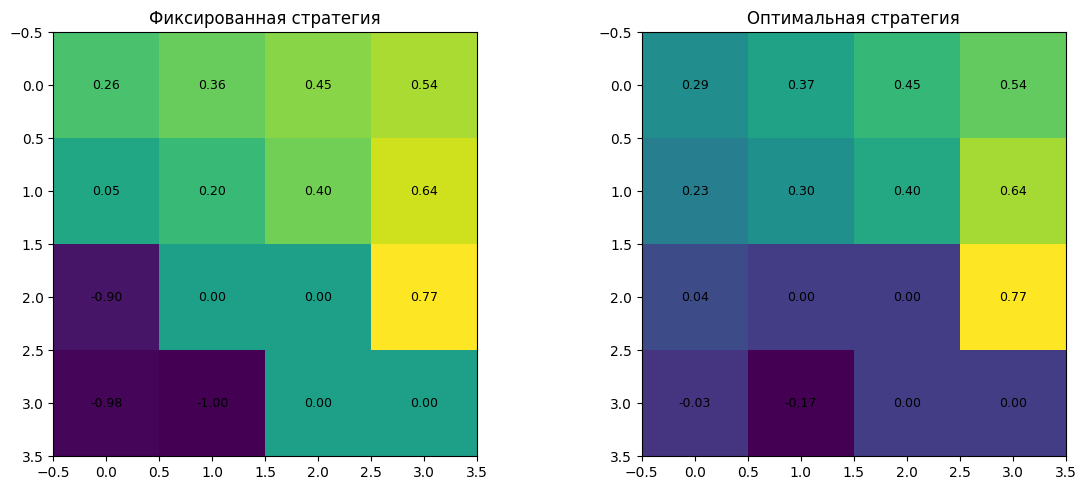

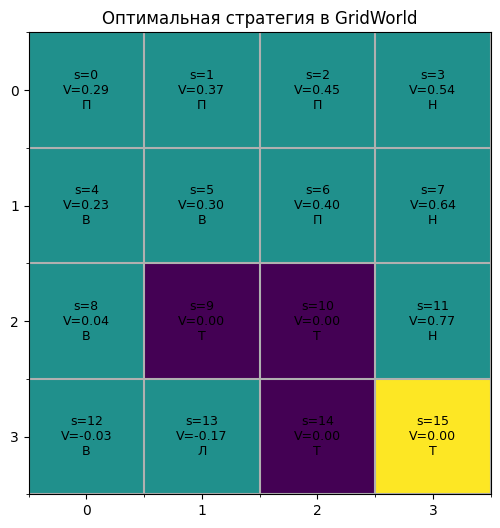

In [27]:
# Задача 4


# DONE: Выполните жадное улучшение стратегии на основе V_pi из задачи 3
greedy_after_eval = policy_improvement(
    P,  # P
    G,  # G
    V_pi,  # V_pi
    terminal_states=env.terminal_states,
    gamma=gamma,
)

# DONE: Запустите полную policy iteration
optimal_policy, optimal_V, pi_history = policy_iteration(
    P,  # P
    G,  # G
    terminal_states=env.terminal_states,
    gamma=gamma,
)

print('Жадно улучшенная стратегия после одной оценки:')
print(greedy_after_eval.reshape(env.n_rows, env.n_cols))

print('\nОптимальная стратегия после policy iteration:')
print(optimal_policy.reshape(env.n_rows, env.n_cols))

print('\nФункция ценности оптимальной стратегии:')
print(np.round(optimal_V.reshape(env.n_rows, env.n_cols), 3))

print('\nЦенность стартового состояния:')
print(
    '  исходная стратегия  :',
    round(V_pi[env.pos_to_state(env.start)], 3)
)
print(
    '  оптимальная стратегия:',
    round(optimal_V[env.pos_to_state(env.start)], 3)
)

# DONE: Постройте тепловые карты для исходной и оптимальной стратегий рядом
_, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, values, title in zip(
    axes,
    [V_pi.reshape(env.n_rows, env.n_cols),
     optimal_V.reshape(env.n_rows, env.n_cols)],
    ['Фиксированная стратегия', 'Оптимальная стратегия']
):
    ax.imshow(values, cmap='viridis')
    ax.set_title(title)
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            ax.text(
                c,
                r,
                f'{values[r, c]:.2f}',
                ha='center',
                va='center',
                fontsize=9
            )

plt.tight_layout()
plt.show()

env.render(
    values=optimal_V,
    policy=optimal_policy,
    title='Оптимальная стратегия в GridWorld'
)

### Интерпретация результата

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

В этом блоке точные методы сравниваются с выборочными. Затем от оценки фиксированной стратегии мы переходим к обучению управления.

## Задача 5. First-visit Monte Carlo и сравнение с точной оценкой

### Постановка задачи

Оцените ту же фиксированную стратегию методом `first-visit Monte Carlo`, используя много эпизодов, и сравните результат с точной оценкой из задачи 3.

### Теоретический минимум

В `first-visit Monte Carlo` для каждого состояния усредняется доходность только по первому посещению состояния в эпизоде. Метод не требует знания тензора переходов, но использует завершенные эпизоды и потому имеет более высокую дисперсию.

**Зачем это нужно:**  сравнение с точной оценкой позволяет понять, насколько быстро Monte Carlo сходится к правильным значениям.

**Декомпозиция задачи:**
1. Запустить `first_visit_mc_evaluation` с 2000 эпизодами, передав `reference_V=V_pi`.
2. Вывести матрицу числа посещений — убедиться, что все состояния посещались.
3. Вычислить MSE между `V_mc` и `V_pi` (только по посещенным состояниям).
4. Построить кривую снижения ошибки по эпизодам.
5. Построить тепловую карту разностей `V_mc - V_pi`.

**Подсказки для размышления:**
- Почему для некоторых состояний число посещений может быть нулевым?
- Как ведет себя кривая ошибки: быстро падает и стабилизируется или медленно?
- Какие состояния оцениваются с наибольшей ошибкой и почему?

**Полезные инструменты:** `first_visit_mc_evaluation()`, `mse()`, `visit_counts > 0` (маска посещенных).

Число посещений состояний:
[[2000 1831 1671 1489]
 [ 206  366  656 1893]
 [  23    0    0 1871]
 [   2    2    0    0]]

Оценка Monte Carlo:
[[ 0.278  0.372  0.471  0.558]
 [ 0.06   0.217  0.445  0.66 ]
 [-0.998  0.     0.     0.783]
 [-0.985 -1.     0.     0.   ]]

MSE относительно точной оценки: 0.00123


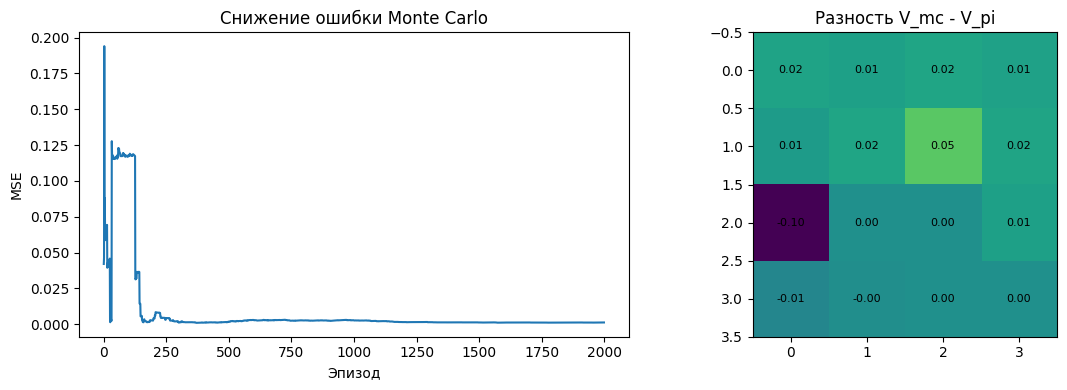

In [28]:
# Задача 5


# DONE: Запустите first-visit Monte Carlo с 2000 эпизодами
# Передайте reference_V=V_pi, чтобы получить кривую ошибки
V_mc, visit_counts, mc_errors = first_visit_mc_evaluation(
    env,
    right_then_down_policy,         # стратегия
    gamma=gamma,
    n_episodes=2000,  # 2000
    seed=SEED,
    reference_V=V_pi,
)

mask_mc = visit_counts > 0

print('Число посещений состояний:')
print(visit_counts.reshape(env.n_rows, env.n_cols).astype(int))

print('\nОценка Monte Carlo:')
print(np.round(V_mc.reshape(env.n_rows, env.n_cols), 3))

print(
    '\nMSE относительно точной оценки:',
    round(mse(V_mc, V_pi, mask=mask_mc), 5)
)

# DONE: Постройте два графика:
# левый — кривая снижения MSE по эпизодам
# правый — тепловая карта разностей V_mc - V_pi
_, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0]: кривая ошибки
axes[0].plot(mc_errors)
axes[0].set_title('Снижение ошибки Monte Carlo')
axes[0].set_xlabel('Эпизод')
axes[0].set_ylabel('MSE')

# axes[1]: разность V_mc - V_pi
diff_grid = (V_mc - V_pi).reshape(env.n_rows, env.n_cols)
axes[1].imshow(diff_grid, vmin=-0.1, vmax=0.1, cmap='viridis')
axes[1].set_title('Разность V_mc - V_pi')
for r in range(env.n_rows):
    for c in range(env.n_cols):
        axes[1].text(
            c,
            r,
            f'{diff_grid[r, c]:.2f}',
            ha='center',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

### Интерпретация результата


## Задача 6. TD(0) против Monte Carlo при одинаковом бюджете эпизодов

### Постановка задачи

Обучите оценку фиксированной стратегии методом TD(0) и сравните ее с Monte Carlo при одинаковом числе эпизодов. Используйте точную оценку $V^{\pi}$ как эталон.

### Теоретический минимум

TD(0) использует одношаговый бутстрэп:
$$V(s_t) \leftarrow V(s_t) + \alpha (r_{t+1} + \gamma V(s_{t+1}) - V(s_t)).$$
В отличие от Monte Carlo, метод не ждет конца эпизода, поэтому информация начинает распространяться раньше.

**Зачем это нужно:** при ограниченном числе взаимодействий со средой выбор метода оценки существенно влияет на точность.

**Декомпозиция задачи:**
1. Задать `n_budget = 400` эпизодов.
2. Запустить `first_visit_mc_evaluation` с бюджетом 400 и `reference_V=V_pi`.
3. Запустить `td0_evaluation` с `alpha=0.12`, бюджетом 400 и `reference_V=V_pi`.
4. Напечатать финальные MSE обоих методов.
5. Построить три панели: кривые ошибок на одном графике, тепловые карты MC и TD(0).

**Подсказки для размышления:**
- Почему TD(0) использует `alpha` (шаг обучения), а Monte Carlo — нет?
- Что означает «бутстрэп» в контексте TD? Чем это отличается от MC?
- Какой из методов должен выиграть при малом бюджете, согласно теоретической гипотезе работы?

**Полезные инструменты:** `first_visit_mc_evaluation()`, `td0_evaluation()`, `mse()`, `moving_average()`.

Финальная MSE Monte Carlo: 0.0011
Финальная MSE TD(0)      : 0.13104


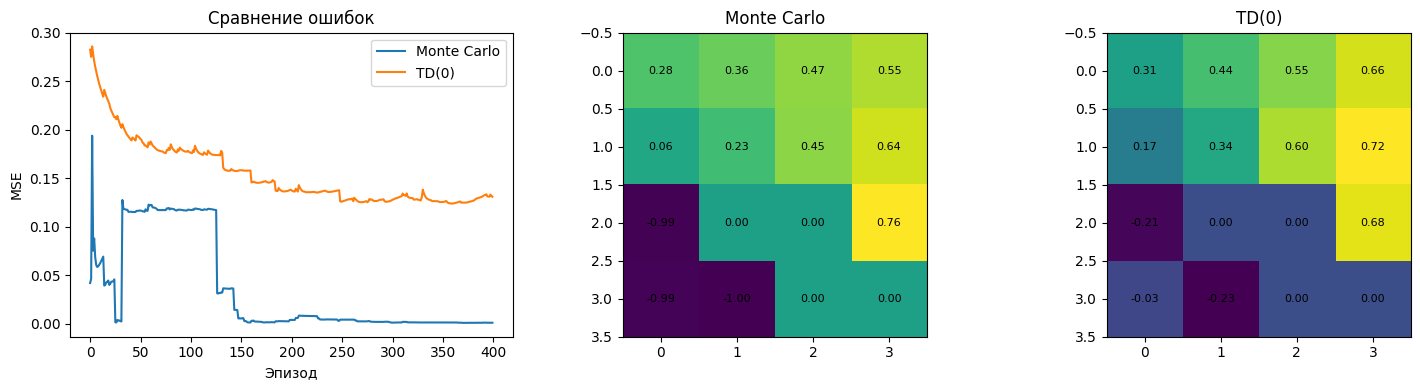

In [29]:
# Задача 6


n_budget = 400

# DONE: Запустите Monte Carlo с бюджетом n_budget
V_mc_small, counts_mc_small, mc_errors_small = first_visit_mc_evaluation(
    env,
    right_then_down_policy,
    gamma=gamma,
    n_episodes=n_budget,
    seed=SEED,
    reference_V=V_pi,
)

# DONE: Запустите TD(0) с alpha=0.12 и бюджетом n_budget
V_td, td_errors = td0_evaluation(
    env,
    right_then_down_policy,
    gamma=gamma,
    alpha=0.12,
    n_episodes=n_budget,
    seed=SEED,
    reference_V=V_pi,
)

print(
    'Финальная MSE Monte Carlo:',
    round(mse(V_mc_small, V_pi, mask=counts_mc_small > 0), 5)
)
print('Финальная MSE TD(0)      :', round(mse(V_td, V_pi), 5))

# DONE: Постройте три панели:
# [0] — кривые ошибок MC и TD(0) на одном графике (с легендой)
# [1] — тепловая карта V_mc_small
# [2] — тепловая карта V_td
_, axes = plt.subplots(1, 3, figsize=(15, 4))

# axes[0]: кривые ошибок
axes[0].plot(mc_errors_small, label='Monte Carlo')
axes[0].plot(td_errors, label='TD(0)')
axes[0].set_title('Сравнение ошибок')
axes[0].set_xlabel('Эпизод')
axes[0].set_ylabel('MSE')
axes[0].legend()

for ax, values, title in zip(
    axes[1:],
    # V_mc_small и V_td, reshaped
    [V_mc_small.reshape(env.n_rows, env.n_cols),
     V_td.reshape(env.n_rows, env.n_cols)],
    ['Monte Carlo', 'TD(0)']
):
    ax.imshow(values)
    ax.set_title(title)
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            ax.text(c, r, f'{values[r, c]:.2f}',
                    ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Интерпретация результата


## Задача 7. SARSA на среде Cliff Walking

### Постановка задачи

Реализуйте обучение управления методом SARSA в среде `CliffWalking`, постройте график суммарной награды по эпизодам и визуализируйте жадную стратегию после обучения.

### Теоретический минимум

SARSA — это `on-policy` метод. Он обновляет \(Q(s,a)\) с учетом того действия, которое стратегия действительно выберет на следующем шаге. Поэтому оценка включает эффект текущего режима исследования.

**Зачем это нужно:**  
SARSA на Cliff Walking — классический пример; он хорошо показывает, как on-policy алгоритм адаптируется к риску.

**Декомпозиция задачи:**
1. Создать среду `CliffWalking(seed=SEED)`.
2. Запустить `sarsa(alpha=0.5, gamma=1.0, epsilon=0.10, n_episodes=450)`.
3. Извлечь жадную стратегию через `greedy_policy_from_Q`.
4. Выполнить жадный прогон через `rollout_greedy` и вывести длину и награду.
5. Построить график с сырыми наградами и скользящим средним (окно 20).
6. Визуализировать жадную стратегию через `cliff_env.render()`.

**Подсказки для размышления:**
- Почему SARSA использует `a_next = epsilon_greedy(...)` при обновлении, а не `argmax`?
- Как выглядит «осторожная» стратегия на карте Cliff Walking? Какого пути избегает агент?
- Почему кривая наград остается шумной даже после многих эпизодов?

**Полезные инструменты:** `sarsa()`, `greedy_policy_from_Q()`, `rollout_greedy()`, `moving_average()`, `CliffWalking.render()`

Длина жадной траектории SARSA: 17
Суммарная награда жадной траектории: -17.0


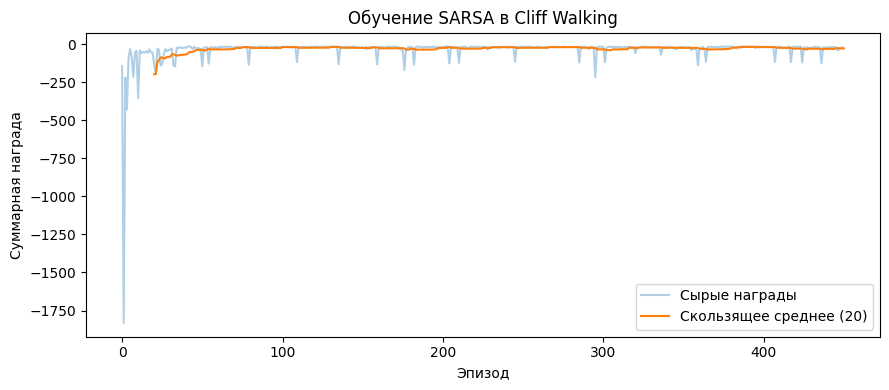

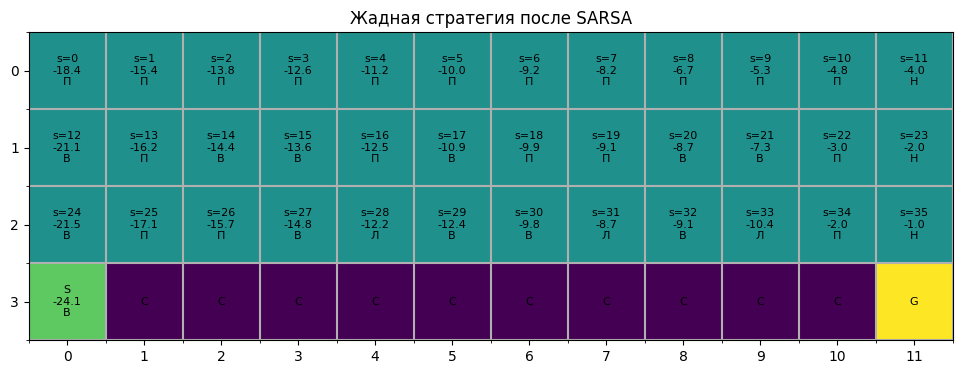

In [30]:
# Задача 7


# DONE: Создайте среду CliffWalking
cliff_env = CliffWalking(seed=SEED)

# DONE: Запустите SARSA (alpha=0.5, gamma=1.0, epsilon=0.10, n_episodes=450)
Q_sarsa, returns_sarsa = sarsa(
    cliff_env,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.10,
    n_episodes=450,
    max_steps=500,
    seed=SEED,
)

# DONE: Извлеките жадную стратегию
policy_sarsa = greedy_policy_from_Q(Q_sarsa)

# DONE: Выполните жадный прогон и выведите длину и суммарную награду
trajectory_sarsa, greedy_return_sarsa = rollout_greedy(
    CliffWalking(seed=SEED),
    Q_sarsa,
    max_steps=100,
)
print('Длина жадной траектории SARSA:', len(trajectory_sarsa) - 1)
print('Суммарная награда жадной траектории:', greedy_return_sarsa)

# DONE: Постройте график: сырые награды (alpha=0.35) + скользящее среднее (окно 20)
_, ax = plt.subplots(figsize=(9, 4))
ax.plot(returns_sarsa, alpha=0.35, label='Сырые награды')
window = 20
ma = moving_average(returns_sarsa, window=window)
ax.plot(np.arange(len(ma)) + window,
        ma,
        label=f'Скользящее среднее ({window})')
ax.set_title('Обучение SARSA в Cliff Walking')
ax.set_xlabel('Эпизод')
ax.set_ylabel('Суммарная награда')
ax.legend()
plt.tight_layout()
plt.show()

# DONE: Визуализируйте жадную стратегию
cliff_env.render(
    q_values=Q_sarsa,
    policy=policy_sarsa,
    title='Жадная стратегия после SARSA'
)

### Интерпретация результата


---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

В этом блоке сравниваются разные алгоритмы управления и анализируется влияние режима исследования.

## Задача 8. Сравнение SARSA и Q-learning

### Постановка задачи

Сравните SARSA и Q-learning на одной и той же среде `CliffWalking`. Выполните несколько запусков с разными seed и постройте усредненные кривые наград.

### Теоретический минимум

Q-learning — это `off-policy` метод. Он обновляет оценку по жадному максимуму, даже если реальное действие выбрано с исследованием. Поэтому метод стремится к более агрессивной оценке оптимального поведения, тогда как SARSA оценивает поведение текущей политики.

**Зачем это нужно:** разница SARSA–Q-learning — один из самых показательных примеров различия on/off-policy подходов в безопасной и рискованной среде.

**Декомпозиция задачи:**

**A. Многократные запуски**
- Запустить SARSA и Q-learning на каждом из `seeds = [3, 7, 11, 19, 23, 29]`.
- Параметры одинаковые: `alpha=0.5, gamma=1.0, epsilon=0.10, n_episodes=350`.
- Сохранить кривые наград в `all_sarsa` и `all_q`.

**B. Усреднение и визуализация**
- Усреднить кривые по сидам: `mean_sarsa = np.array(all_sarsa).mean(axis=0)`.
- Вывести среднюю награду на последних 50 эпизодах для каждого алгоритма.
- Построить сглаженные кривые на одном графике.

**C. Визуализация итоговых стратегий**
- Обучить оба алгоритма еще раз на `seed=SEED` с 450 эпизодами.
- Отрисовать итоговые жадные стратегии через `render()`.

**Полезные инструменты:** `sarsa()`, `q_learning()`, `greedy_policy_from_Q()`, `moving_average()`, `np.array(...).mean(axis=0)`.

Средняя награда на последних 50 эпизодах:
  SARSA     : -37.48
  Q-learning: -55.67


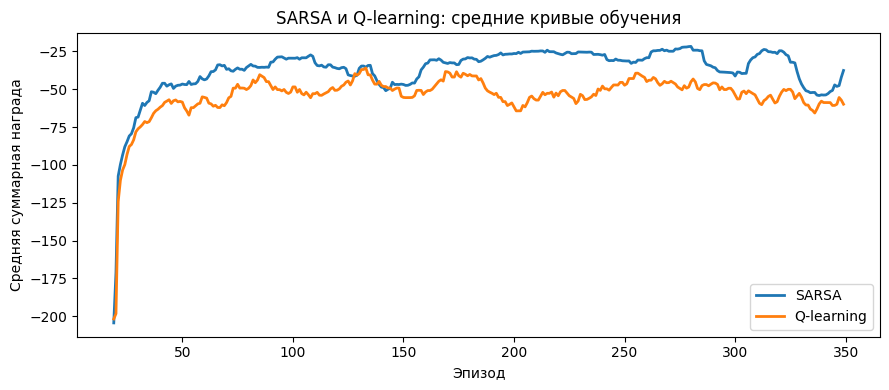

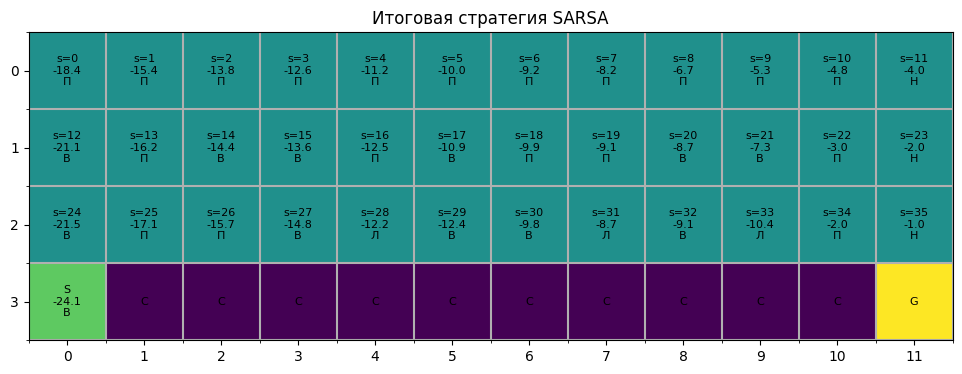

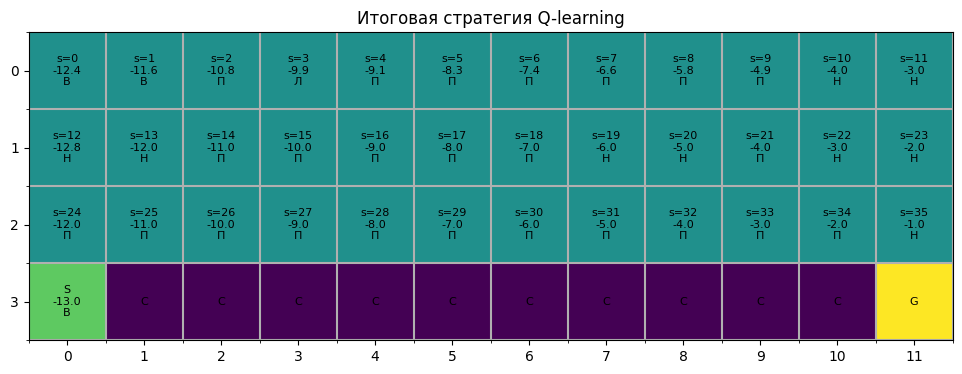

In [ ]:
seeds = [3, 7, 11, 19, 23, 29]
n_episodes_compare = 350

# --- A. Многократные запуски ---
all_sarsa = []
all_q = []

for seed in seeds:
    # TODO: запустите SARSA для каждого seed
    env_s = CliffWalking(seed=seed)
    _, ret_s = sarsa(
        env_s,
        alpha=0.5,
        gamma=1.0,
        epsilon=0.10,
        n_episodes=n_episodes_compare,
        seed=seed,
    )
    all_sarsa.append(ret_s)
    # TODO: запустите Q-learning для каждого seed
    env_q = CliffWalking(seed=seed)
    _, ret_q = q_learning(
        env_q,
        alpha=...,
        gamma=...,
        epsilon=...,
        n_episodes=n_episodes_compare,
        seed=seed,
    )
    all_q.append(ret_q)

# --- B. Усреднение ---
# TODO: Переведите all_sarsa и all_q в numpy-массивы и усредните по сидам

# TODO: Постройте усредненные сглаженные кривые на одном графике

# --- C. Визуализация итоговых стратегий ---
# TODO: Обучите SARSA и Q-learning на seed=SEED с 450 эпизодами

# TODO: Визуализируйте итоговые стратегии обоих алгоритмов

### Интерпретация результата


## Задача 9. Абляция по режиму исследования в Q-learning

### Постановка задачи

Сравните два режима исследования для Q-learning:
1. Фиксированное \(\varepsilon = 0.10\).
2. Затухающее \(\varepsilon\), начинающееся с 0.30 и постепенно уменьшающееся до 0.02.

Сравните скорость обучения и итоговое качество.

### Теоретический минимум

Параметр \(\varepsilon\) управляет компромиссом между исследованием и использованием уже найденных оценок. Слишком маленькое значение может привести к преждевременной фиксации на плохой стратегии, а слишком большое — к избыточному шуму. Затухание \(\varepsilon\) обычно полезно: сначала агент активно исследует среду, а затем постепенно делает поведение более жадным.


**Зачем это нужно:** настройка расписания исследования — важная практическая составляющая RL, влияющая на итоговую стратегию не меньше, чем выбор алгоритма.

**Декомпозиция задачи:**

**A. Фиксированное ε**
- Запустить Q-learning с `epsilon=0.10, epsilon_decay=None, n_episodes=450`.

**B. Затухающее ε**
- Запустить Q-learning с `epsilon=0.30, epsilon_decay={'decay_rate': 0.992, 'min_epsilon': 0.02}, n_episodes=450`.

**C. Сравнение**
- Вывести средние награды на последних 50 эпизодах для обоих режимов.
- Вывести длину и суммарную награду жадной траектории (`rollout_greedy`) для каждого.
- Построить сглаженные кривые на одном графике.
- Визуализировать итоговые стратегии через `render()`.

**Подводящие вопросы:**
- Почему кривая с фиксированным ε остается более шумной ближе к концу обучения?
- Когда затухающее ε может быть **хуже** фиксированного?
- Как бы изменился результат, если бы вместо ε-greedy использовалась стратегия Softmax?

**Полезные инструменты:** `q_learning(epsilon_decay=...)`, `rollout_greedy()`, `moving_average()`, `np.mean()`.

Средняя награда на последних 50 эпизодах:
  фиксированное epsilon: -63.38
  затухающее epsilon   : -15.2

Жадная траектория после обучения:
  фиксированное epsilon: длина = 13 , награда = -13.0
  затухающее epsilon   : длина = 13 , награда = -13.0


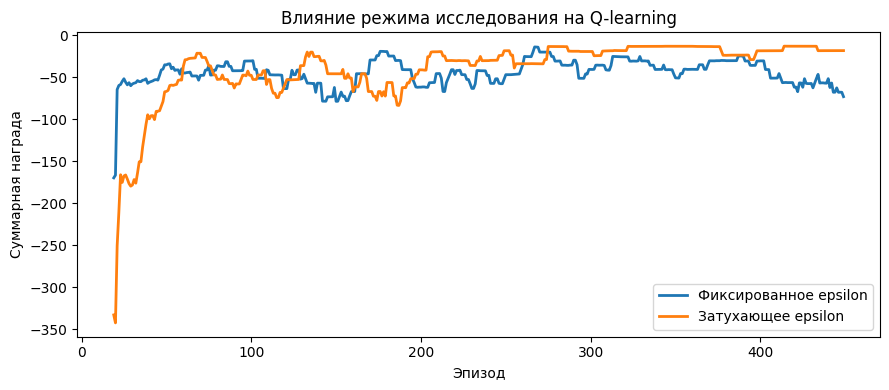

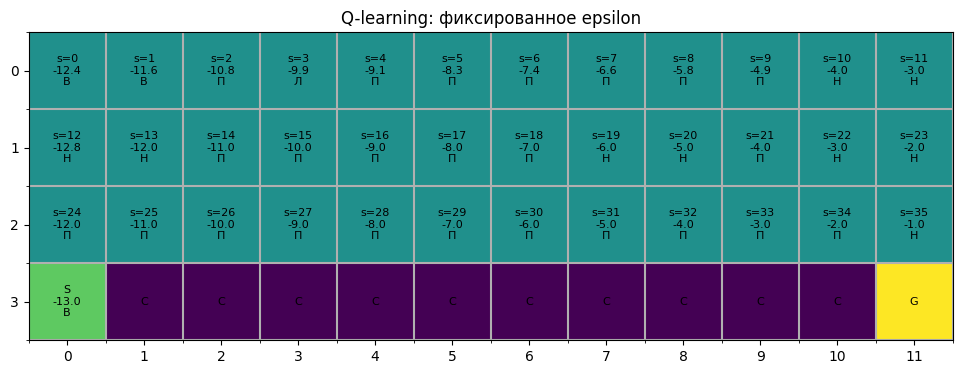

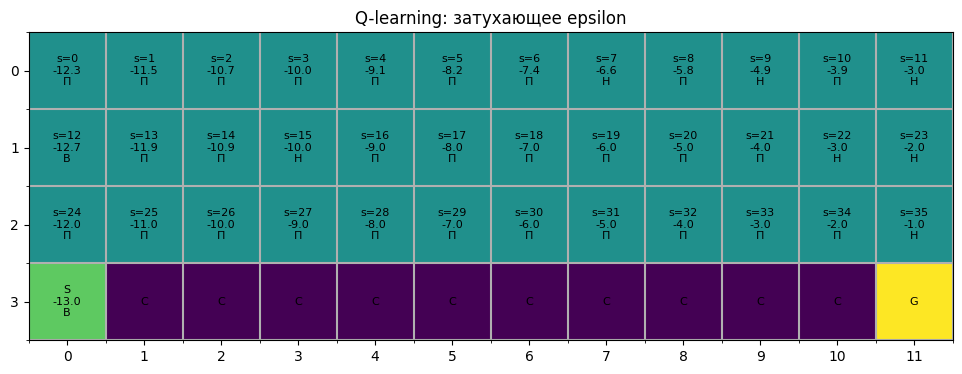

In [ ]:
# --- A. Фиксированное epsilon ---
cliff_fixed = ...

# --- B. Затухающее epsilon ---
cliff_decay = ...

# TODO: Извлеките жадные стратегии
policy_fixed = ...
policy_decay = ...

# TODO: Выполните жадные прогоны и сохраните результаты

# --- C. Сравнение ---

# TODO: Постройте сглаженные кривые обоих режимов на одном графике

# TODO: Визуализируйте итоговые стратегии обоих режимов

### Интерпретация результата

## Интерпретация результатов

Проведенные эксперименты позволяют сделать несколько общих наблюдений.

Во-первых, точные методы на основе уравнения Беллмана дают удобный эталон для анализа поведения выборочных алгоритмов. На небольшой табличной среде хорошо видно, как оценка функции ценности распространяется от терминальных состояний к начальному состоянию.

Во-вторых, Monte Carlo и TD(0) решают одну и ту же задачу, но делают это разными способами. Monte Carlo опирается на завершенные эпизоды и потому обладает большей дисперсией, тогда как TD(0) использует бутстрэп и начинает обновлять значения сразу. Это особенно важно при ограниченном бюджете взаимодействий.

В-третьих, в задачах управления важно различать `on-policy` и `off-policy` подходы. SARSA учитывает реальный режим исследования и поэтому чаще формирует осторожное поведение в опасной среде. Q-learning ориентируется на жадный максимум и потому чаще стремится к более короткому, но рискованному пути.

В-четвертых, параметры исследования заметно влияют на итог обучения. Режим \(\varepsilon\)-greedy — не второстепенная техническая деталь, а один из основных факторов, определяющих скорость сходимости, устойчивость и качество финальной стратегии.

## Выводы

1. Среду обучения с подкреплением удобно анализировать как марковский процесс принятия решений с явными переходами, наградами и коэффициентом дисконтирования.

2. Функция ценности — центральный объект обучения: она связывает локальные награды с долгосрочным качеством поведения и позволяет улучшать стратегию через жадный выбор действия.

3. Динамическое программирование дает точные решения при наличии модели среды, но выборочные методы остаются необходимыми, когда модель неизвестна и доступны только эпизоды взаимодействия.

4. Monte Carlo и TD решают задачу оценки стратегии по-разному: Monte Carlo проще концептуально, а TD эффективнее распространяет информацию в условиях малого числа эпизодов.

5. В задачах управления различие между SARSA и Q-learning имеет содержательный смысл. Оно проявляется в том, насколько алгоритм учитывает риск, связанный с исследованием.

6. Практически важный вывод состоит в том, что качество обучения определяется не только выбором алгоритма, но и режимом исследования. Настройка \(\alpha\), \(\gamma\) и \(\varepsilon\) влияет на устойчивость и итоговую стратегию не меньше, чем сама формула обновления.